# ML-4: Comprehensive Model Evaluation, Threshold Tuning & Pipeline Export

This notebook evaluates the winning failure prediction model selected in ML-3, selects an optimal decision threshold using **Out-of-Fold (OOF) cross-validation predictions**, evaluates performance ONCE on the untouched holdout test set, and exports the final reusable failure pipeline.

## Key Objectives:
1. **Load ML-3 Winning Pipeline**: Ingest `ml/models/best_model.joblib` without altering model selection.
2. **Leakage-Free OOF Threshold Tuning**: Use 5-fold Stratified OOF probability predictions on the training set to select an optimal decision threshold (maximizing F1 while prioritizing Recall). The test set is **never** used for threshold tuning.
3. **Untouched Test Set Evaluation**: Fit the winning pipeline on the complete 80% training set and evaluate ONCE on the untouched 20% test set (comparing default 0.50 threshold vs OOF selected threshold).
4. **Visualizations**: Render Confusion Matrix, ROC Curve, Precision-Recall Curve, and Threshold vs Metric curves.
5. **Export Final Pipeline & SHAP Compatibility**: Export `ml/models/final_failure_pipeline.joblib` and `final_evaluation_metrics.json` while preserving feature names for SHAP explainability.

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix, 
    precision_recall_curve, roc_curve
)

sys.path.append(os.path.abspath("../src"))
from feature_engineering import EXCLUDED_COLS, TARGET_COL

## 1. Load ML-3 Candidate Model & Reproduce Train/Test Split

In [2]:
data_path = "../../data/cleaned_predictive_maintenance.csv"
if not os.path.exists(data_path):
    data_path = "../../data/ai4i2020.csv"

df = pd.read_csv(data_path)
feature_cols = [c for c in df.columns if c not in EXCLUDED_COLS and c != TARGET_COL]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

# Reproduce exact stratified 80/20 train/test split from ML-3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load ML-3 Candidate Model Artifact
best_model_path = "../models/best_model.joblib"
if not os.path.exists(best_model_path):
    raise FileNotFoundError("ML-3 artifact not found at ../models/best_model.joblib. Run ML-3 first.")

ml3_artifact = joblib.load(best_model_path)
winning_model_name = ml3_artifact["model_name"]
selected_pipeline = ml3_artifact["pipeline"]

print(f"Loaded Selected Candidate Pipeline: '{winning_model_name}'")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape} (Untouched)")

Loaded Selected Candidate Pipeline: 'Balanced Random Forest'
X_train shape: (8000, 6), X_test shape: (2000, 6) (Untouched)


## 2. Out-of-Fold (OOF) Decision Threshold Selection

We generate 5-fold Stratified OOF probability predictions on the training set using `cross_val_predict`. We sweep thresholds from 0.05 to 0.95 on the OOF predictions to find the threshold maximizing F1-Score.

OOF Threshold Selection Summary:
  • Default Threshold: 0.50
  • Selected OOF Optimal Threshold: 0.49
  • OOF Metrics @ 0.49 -> F1: 0.8677, Recall: 0.8229, Precision: 0.9177


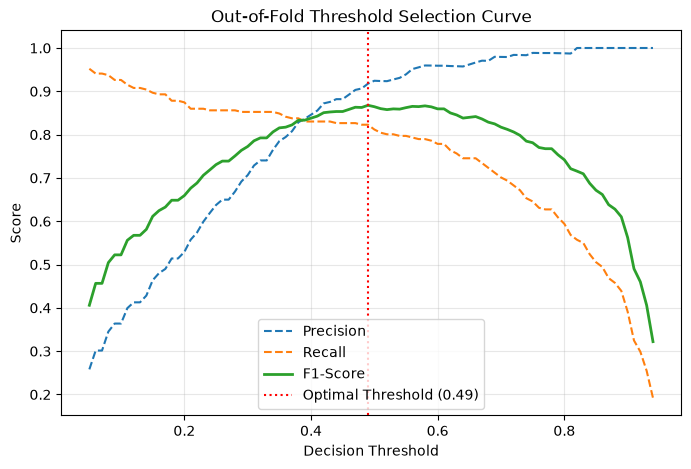

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = cross_val_predict(
    selected_pipeline, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
best_threshold = 0.50
best_oof_f1 = -1.0
best_oof_rec = -1.0
best_oof_prec = -1.0

thresh_records = []
for thresh in thresholds:
    preds = (oof_probs >= thresh).astype(int)
    prec = precision_score(y_train, preds, zero_division=0)
    rec = recall_score(y_train, preds, zero_division=0)
    f1 = f1_score(y_train, preds, zero_division=0)
    
    thresh_records.append({"threshold": thresh, "precision": prec, "recall": rec, "f1": f1})
    
    if f1 > best_oof_f1 or (np.isclose(f1, best_oof_f1) and rec > best_oof_rec):
        best_oof_f1 = f1
        best_threshold = float(thresh)
        best_oof_rec = rec
        best_oof_prec = prec

thresh_df = pd.DataFrame(thresh_records)

print(f"OOF Threshold Selection Summary:")
print(f"  • Default Threshold: 0.50")
print(f"  • Selected OOF Optimal Threshold: {best_threshold:.2f}")
print(f"  • OOF Metrics @ {best_threshold:.2f} -> F1: {best_oof_f1:.4f}, Recall: {best_oof_rec:.4f}, Precision: {best_oof_prec:.4f}")

# Plot Threshold vs Metrics Curve
plt.figure(figsize=(8, 5))
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', linestyle='--')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='Recall', linestyle='--')
plt.plot(thresh_df['threshold'], thresh_df['f1'], label='F1-Score', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({best_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Out-of-Fold Threshold Selection Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Final Model Fitting & Untouched Test Set Evaluation

We fit `selected_pipeline` on the complete 80% training set (`X_train`, `y_train`) and evaluate ONCE on the untouched test set (`X_test`, `y_test`).

In [4]:
# Fit pipeline on complete 80% training set
selected_pipeline.fit(X_train, y_train)

# Extract recoverable feature names
preprocessor = selected_pipeline.named_steps['preprocessor']
feature_names = list(preprocessor.get_feature_names_out())

# Predict probabilities on untouched test set
test_probs = selected_pipeline.predict_proba(X_test)[:, 1]

test_preds_default = (test_probs >= 0.50).astype(int)
test_preds_selected = (test_probs >= best_threshold).astype(int)

test_metrics_default = {
    "Accuracy": round(accuracy_score(y_test, test_preds_default), 4),
    "Precision": round(precision_score(y_test, test_preds_default), 4),
    "Recall": round(recall_score(y_test, test_preds_default), 4),
    "F1-Score": round(f1_score(y_test, test_preds_default), 4),
    "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4),
    "PR-AUC": round(average_precision_score(y_test, test_probs), 4)
}

test_metrics_selected = {
    "Accuracy": round(accuracy_score(y_test, test_preds_selected), 4),
    "Precision": round(precision_score(y_test, test_preds_selected), 4),
    "Recall": round(recall_score(y_test, test_preds_selected), 4),
    "F1-Score": round(f1_score(y_test, test_preds_selected), 4),
    "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4),
    "PR-AUC": round(average_precision_score(y_test, test_probs), 4)
}

print("Final Test Metrics (Default Threshold = 0.50):")
for k, v in test_metrics_default.items():
    print(f"  • {k}: {v}")
    
print(f"\nFinal Test Metrics (Selected OOF Threshold = {best_threshold:.2f}):")
for k, v in test_metrics_selected.items():
    print(f"  • {k}: {v}")

Final Test Metrics (Default Threshold = 0.50):
  • Accuracy: 0.992
  • Precision: 0.9483
  • Recall: 0.8088
  • F1-Score: 0.873
  • ROC-AUC: 0.974
  • PR-AUC: 0.8683

Final Test Metrics (Selected OOF Threshold = 0.49):
  • Accuracy: 0.992
  • Precision: 0.9483
  • Recall: 0.8088
  • F1-Score: 0.873
  • ROC-AUC: 0.974
  • PR-AUC: 0.8683


## 4. Evaluation Visualizations

We generate confusion matrix heatmaps, ROC curves, and Precision-Recall curves on the test set for visual presentation.

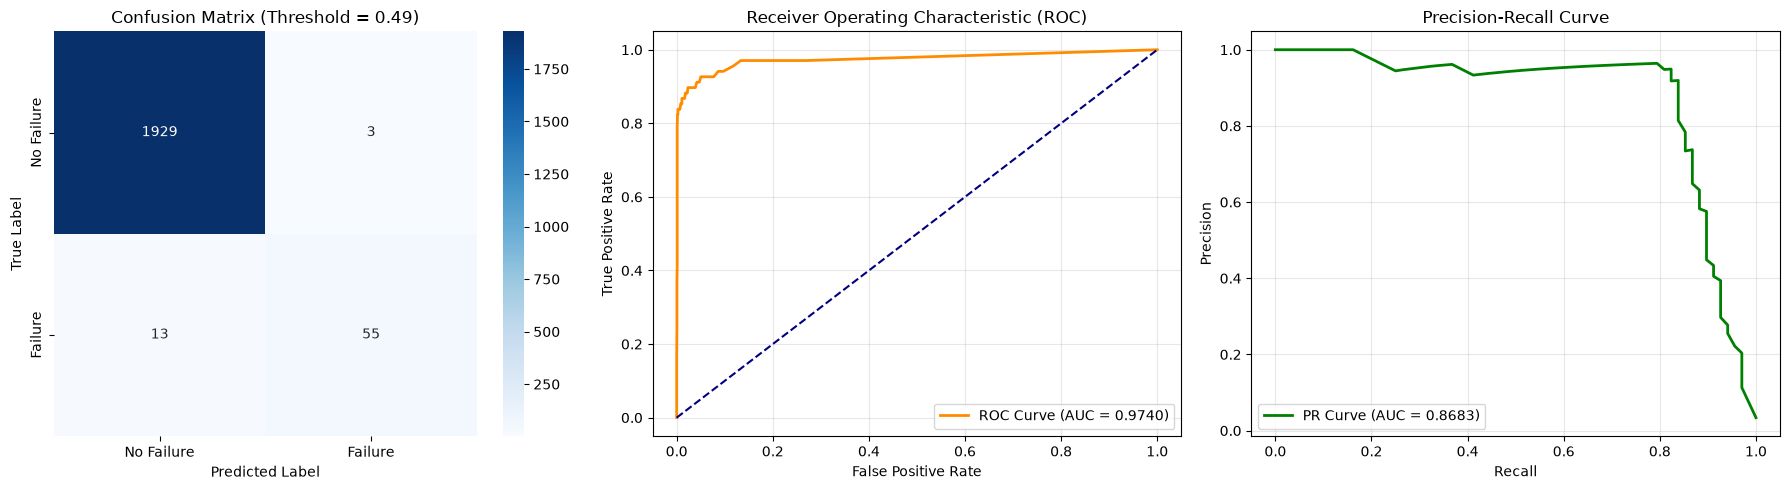

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, test_preds_selected)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
axes[0].set_title(f'Confusion Matrix (Threshold = {best_threshold:.2f})')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {test_metrics_selected["ROC-AUC"]:.4f})', color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_probs)
axes[2].plot(rec_curve, prec_curve, label=f'PR Curve (AUC = {test_metrics_selected["PR-AUC"]:.4f})', color='green', lw=2)
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Export Reusable Final Failure Pipeline Package

We export the fitted pipeline, selected decision threshold, recoverable feature names, and metadata to `ml/models/final_failure_pipeline.joblib` and `ml/models/final_evaluation_metrics.json`.

In [6]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

final_pipeline_bundle = {
    "pipeline": selected_pipeline,
    "winning_model_name": winning_model_name,
    "selected_threshold": best_threshold,
    "feature_names": feature_names,
    "input_feature_schema": feature_cols,
    "test_metrics": test_metrics_selected,
    "test_metrics_default": test_metrics_default,
    "oof_f1": best_oof_f1
}

bundle_path = os.path.join(models_dir, "final_failure_pipeline.joblib")
joblib.dump(final_pipeline_bundle, bundle_path)
print(f"Saved final failure pipeline bundle to: {os.path.abspath(bundle_path)}")

metrics_json_path = os.path.join(models_dir, "final_evaluation_metrics.json")
with open(metrics_json_path, "w") as f:
    json.dump({
        "winning_model": winning_model_name,
        "selected_threshold": best_threshold,
        "oof_best_f1": best_oof_f1,
        "test_metrics_default": test_metrics_default,
        "test_metrics_selected": test_metrics_selected,
        "confusion_matrix": cm.tolist()
    }, f, indent=2)
print(f"Saved final evaluation metrics JSON to: {os.path.abspath(metrics_json_path)}")

Saved final failure pipeline bundle to: c:\Users\bingu\OneDrive\Desktop\cognizant\predictive-maintenance\ml\models\final_failure_pipeline.joblib
Saved final evaluation metrics JSON to: c:\Users\bingu\OneDrive\Desktop\cognizant\predictive-maintenance\ml\models\final_evaluation_metrics.json
